In [2]:
# ============================================================
# Cell 1: 导入库
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE, ADASYN

# 图形设置
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

# 配置参数
TARGET_SURFACE = 2  # Вариант 7 -> 表面类型2
RANDOM_STATE = 42
TEST_SIZE = 0.4

print("✅ 所有库导入成功")
print(f"目标表面类型: {TARGET_SURFACE}")
print(f"随机种子: {RANDOM_STATE}")

# 检查文件
files = ['Data_Set_(A+B).xlsx', 'Data_Set_C.xlsx']
for f in files:
    if os.path.exists(f):
        print(f"✅ 找到文件：{f}")
    else:
        print(f"❌ 找不到文件：{f}")

✅ 所有库导入成功
目标表面类型: 2
随机种子: 42
✅ 找到文件：Data_Set_(A+B).xlsx
✅ 找到文件：Data_Set_C.xlsx


In [3]:
# ============================================================
# Cell 2: 加载数据并查看分布
# ============================================================
df_train = pd.read_excel('Data_Set_(A+B).xlsx')
df_test = pd.read_excel('Data_Set_C.xlsx')

print("=" * 60)
print("训练集 Data_Set_(A+B)")
print("=" * 60)
print(f"形状: {df_train.shape}")
print(f"\n目标列 'Type' 分布:")
print(df_train['Type'].value_counts().sort_index())

print("\n" + "=" * 60)
print("测试集 Data_Set_C")
print("=" * 60)
print(f"形状: {df_test.shape}")
print(df_test['Type'].value_counts().sort_index())

训练集 Data_Set_(A+B)
形状: (176, 16)

目标列 'Type' 分布:
Type
1    35
2    36
3    33
4    36
5    36
Name: count, dtype: int64

测试集 Data_Set_C
形状: (58, 16)
Type
1    11
2    12
3    11
4    12
5    12
Name: count, dtype: int64


In [4]:
# 检查I1, I2, I3是否有负值
print("I1 范围:", df_train['I1'].min(), "到", df_train['I1'].max())
print("I2 范围:", df_train['I2'].min(), "到", df_train['I2'].max())
print("I3 范围:", df_train['I3'].min(), "到", df_train['I3'].max())
print("\n是否有负值？")
print("I1负值数量:", (df_train['I1'] < 0).sum())
print("I2负值数量:", (df_train['I2'] < 0).sum())
print("I3负值数量:", (df_train['I3'] < 0).sum())

I1 范围: 0.03760682 到 1.36500782352941
I2 范围: 0.0 到 1.56108529411765
I3 范围: 0.02905982 到 1.22322941176471

是否有负值？
I1负值数量: 0
I2负值数量: 0
I3负值数量: 0


In [5]:
# ============================================================
# Cell 3: V2特征计算函数
# ============================================================
def calculate_V2_features(df, R=40, L=125, alpha=0, theta_deg=30):
    """
    计算V2特征集 (Вариант 7)
    V2 = {Vx, Vy, Omega, Ix, Iy, Iphi, I_sigma}
    """
    theta_rad = np.radians(theta_deg)
    alpha_rad = np.radians(alpha)
    
    # 三角函数值
    cos_alpha_minus_theta = np.cos(alpha_rad - theta_rad)
    sin_alpha = np.sin(alpha_rad)
    cos_alpha_plus_theta = np.cos(alpha_rad + theta_rad)
    sin_alpha_minus_theta = np.sin(alpha_rad - theta_rad)
    cos_alpha = np.cos(alpha_rad)
    sin_alpha_plus_theta = np.sin(alpha_rad + theta_rad)
    
    # 速度变换矩阵 (公式1)
    M_vel = np.array([
        [-2/3 * cos_alpha_minus_theta,  2/3 * sin_alpha,         2/3 * cos_alpha_plus_theta],
        [-2/3 * sin_alpha_minus_theta, -2/3 * cos_alpha,         2/3 * sin_alpha_plus_theta],
        [1/(3*L),                       1/(3*L),                 1/(3*L)]
    ]) * R
    
    # 电流变换矩阵 (公式2)
    M_current = np.array([
        [-2/3 * cos_alpha_minus_theta,  2/3 * sin_alpha,         2/3 * cos_alpha_plus_theta],
        [-2/3 * sin_alpha_minus_theta, -2/3 * cos_alpha,         2/3 * sin_alpha_plus_theta],
        [1/3,                           1/3,                     1/3]
    ])
    
    # 读取数据
    omega = df[['N1', 'N2', 'N3']].values
    currents = df[['I1', 'I2', 'I3']].values
    
    # 计算
    velocities = np.dot(M_vel, omega.T).T
    forces = np.dot(M_current, currents.T).T
    I_sigma = df['I1'].abs() + df['I2'].abs() + df['I3'].abs()
    
    # 构建DataFrame
    V2_df = pd.DataFrame({
        'Vx': velocities[:, 0],
        'Vy': velocities[:, 1],
        'Omega': velocities[:, 2],
        'Ix': forces[:, 0],
        'Iy': forces[:, 1],
        'Iphi': forces[:, 2],
        'I_sigma': I_sigma
    })
    
    return V2_df

print("✅ V2特征计算函数定义完成")

✅ V2特征计算函数定义完成


In [6]:
# ============================================================
# Cell 4: 计算V2特征和划分数据
# ============================================================
# 计算V2特征
V2_train = calculate_V2_features(df_train)
V2_test = calculate_V2_features(df_test)

# 目标变量
y_train_all = (df_train['Type'] == TARGET_SURFACE).astype(int)
y_test = (df_test['Type'] == TARGET_SURFACE).astype(int)

print("=" * 60)
print("V2特征计算完成")
print("=" * 60)
print(f"训练集 V2特征形状: {V2_train.shape}")
print(f"测试集 V2特征形状: {V2_test.shape}")
print(f"\nV2特征名称: {list(V2_train.columns)}")
print(f"\n目标变量分布:")
print(f"训练集 - 0类: {sum(y_train_all==0)}, 1类: {sum(y_train_all==1)}")
print(f"测试集 - 0类: {sum(y_test==0)}, 1类: {sum(y_test==1)}")

# 数据划分
X_all = V2_train.values
y_all = y_train_all.values

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_all
)

X_test = V2_test.values
y_test = y_test.values

print("\n" + "=" * 60)
print("数据划分完成")
print("=" * 60)
print(f"训练集 A: {X_train.shape[0]} (0类={sum(y_train==0)}, 1类={sum(y_train==1)})")
print(f"验证集 B: {X_val.shape[0]} (0类={sum(y_val==0)}, 1类={sum(y_val==1)})")
print(f"测试集 C: {X_test.shape[0]} (0类={sum(y_test==0)}, 1类={sum(y_test==1)})")

V2特征计算完成
训练集 V2特征形状: (176, 7)
测试集 V2特征形状: (58, 7)

V2特征名称: ['Vx', 'Vy', 'Omega', 'Ix', 'Iy', 'Iphi', 'I_sigma']

目标变量分布:
训练集 - 0类: 140, 1类: 36
测试集 - 0类: 46, 1类: 12

数据划分完成
训练集 A: 105 (0类=84, 1类=21)
验证集 B: 71 (0类=56, 1类=15)
测试集 C: 58 (0类=46, 1类=12)


In [7]:
# ============================================================
# Cell 5: 辅助函数定义
# ============================================================
def plot_cv_barchart(cv_scores, title):
    """绘制CV F1条形图"""
    plt.figure(figsize=(8, 6))
    bars = plt.bar(range(1, 5), cv_scores, color='steelblue', edgecolor='black', alpha=0.8)
    plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean = {cv_scores.mean():.4f}')
    plt.fill_between([0.5, 4.5], cv_scores.mean() - cv_scores.std(), 
                     cv_scores.mean() + cv_scores.std(), 
                     alpha=0.2, color='yellow', label=f'Std = {cv_scores.std():.4f}')
    
    for bar, score in zip(bars, cv_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                 f'{score:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.ylabel('F1 Score', fontsize=12)
    plt.xlabel('Fold', fontsize=12)
    plt.title(title, fontsize=14)
    plt.ylim(0, 1)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

def plot_confusion_matrix_custom(y_true, y_pred, title):
    """绘制混淆矩阵"""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap="Blues", interpolation='nearest')
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Other", f"Type {TARGET_SURFACE}"])
    ax.set_yticklabels(["Other", f"Type {TARGET_SURFACE}"])
    
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    return cm

def plot_comparison(y_true, y_pred, title):
    """比较真实值和预测值"""
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(y_true[:50], "bo-", label="True", alpha=0.75, markersize=4)
    ax.plot(y_pred[:50], "rs-", label="Predicted", alpha=0.75, markersize=4)
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("Class (0=Other, 1=Type 2)")
    ax.set_yticks([0, 1])
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

print("✅ 辅助函数定义完成")

✅ 辅助函数定义完成


6. 预实验：超参数自动搜索 (GridSearchCV)
少数类样本数: 21
交叉验证折数: 4

搜索空间:
  hidden_layer_sizes: 9 种
  activation: 3 种
  solver: 2 种
  alpha: 5 种
  总组合数: 270

开始自动搜索...
Fitting 4 folds for each of 270 candidates, totalling 1080 fits

GridSearchCV 搜索结果
最佳参数: {'activation': 'relu', 'alpha': 0.005, 'hidden_layer_sizes': (5,), 'solver': 'lbfgs'}
最佳CV F1分数: 0.9273

前15个最佳配置:
Rank  hidden_layer_sizes activation   solver   alpha      CV F1 mean   CV F1 std
--------------------------------------------------------------------------------
1     (5,)               relu         lbfgs    0.0050     0.9273       0.0823
2     (5,)               relu         lbfgs    0.0005     0.8918       0.0822
3     (5,)               relu         lbfgs    0.0010     0.8918       0.0822
4     (5,)               relu         lbfgs    0.0001     0.8918       0.0822
5     (8,)               relu         lbfgs    0.0100     0.8918       0.0822
6     (15,)              tanh         lbfgs    0.0050     0.8856       0.0770
7     (15, 8) 

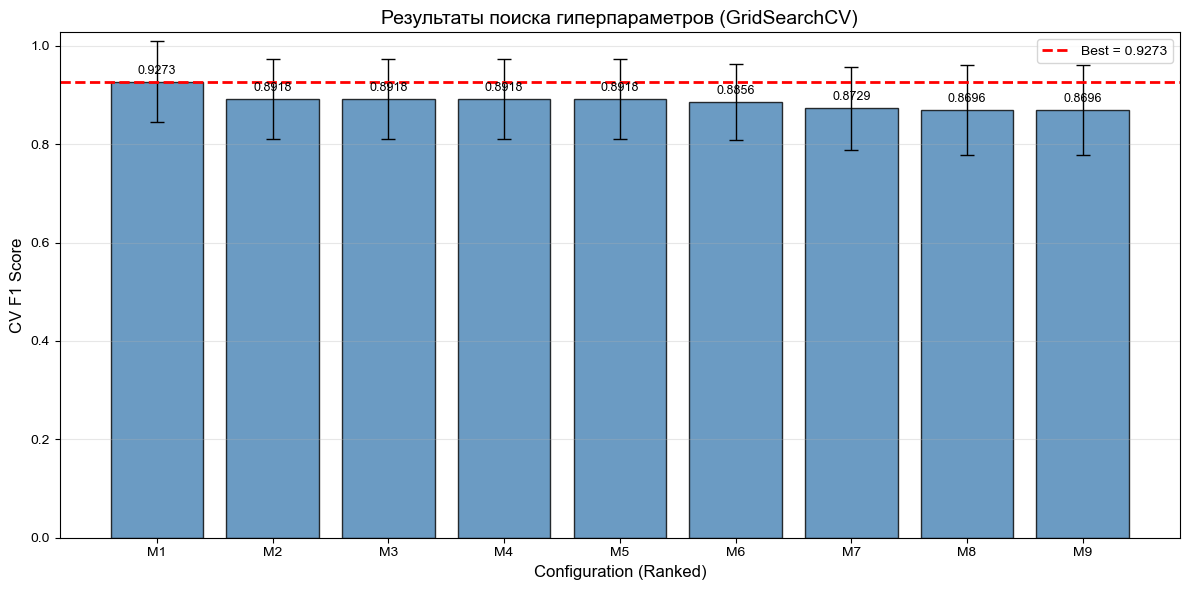


 Результаты поиска гиперпараметров (CV = 4, метрика F1)
№   Архитектура        Активация    Solver   alpha      CV F1 mean   CV F1 std
--------------------------------------------------------------------------------
1   (5,)               relu         lbfgs    0.0050     0.9273       0.0823
2   (5,)               relu         lbfgs    0.0005     0.8918       0.0822
3   (5,)               relu         lbfgs    0.0010     0.8918       0.0822
4   (5,)               relu         lbfgs    0.0001     0.8918       0.0822
5   (8,)               relu         lbfgs    0.0100     0.8918       0.0822
6   (15,)              tanh         lbfgs    0.0050     0.8856       0.0770
7   (15, 8)            relu         lbfgs    0.0001     0.8729       0.0847
8   (10,)              logistic     lbfgs    0.0005     0.8696       0.0915
9   (15, 8)            relu         lbfgs    0.0005     0.8696       0.0915
10  (10,)              logistic     lbfgs    0.0010     0.8696       0.0915
11  (15, 8)            

In [21]:
# ============================================================
# Cell 6: 超参数搜索 (GridSearchCV 自动搜索)
# ============================================================
print("=" * 60)
print("6. 预实验：超参数自动搜索 (GridSearchCV)")
print("=" * 60)

# 标准化数据
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 确定交叉验证折数
minority_count = y_train.sum()
CV_FOLDS = min(4, minority_count)
print(f"少数类样本数: {minority_count}")
print(f"交叉验证折数: {CV_FOLDS}")

# ==================== 定义搜索范围 ====================
# 让 GridSearchCV 自动搜索，你只需要定义范围
param_grid = {
    'hidden_layer_sizes': [(5,), (8,), (10,), (12,), (15,), (20,), (8,4), (10,5), (15,8)],
    'activation': ['tanh', 'relu', 'logistic'],
    'solver': ['adam', 'lbfgs'],
    'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01]
}

print(f"\n搜索空间:")
print(f"  hidden_layer_sizes: {len(param_grid['hidden_layer_sizes'])} 种")
print(f"  activation: {len(param_grid['activation'])} 种")
print(f"  solver: {len(param_grid['solver'])} 种")
print(f"  alpha: {len(param_grid['alpha'])} 种")
print(f"  总组合数: {len(param_grid['hidden_layer_sizes']) * len(param_grid['activation']) * len(param_grid['solver']) * len(param_grid['alpha'])}")

# 基础MLP
mlp = MLPClassifier(
    max_iter=3000,
    random_state=RANDOM_STATE,
    early_stopping=True
)

# GridSearchCV
grid_search = GridSearchCV(
    mlp, param_grid,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\n开始自动搜索...")
grid_search.fit(X_train_scaled, y_train)

# ==================== 输出结果 ====================
print("\n" + "=" * 60)
print("GridSearchCV 搜索结果")
print("=" * 60)
print(f"最佳参数: {grid_search.best_params_}")
print(f"最佳CV F1分数: {grid_search.best_score_:.4f}")

# 获取所有结果并排序
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

# 打印前15个最佳结果
print("\n前15个最佳配置:")
print(f"{'Rank':<5} {'hidden_layer_sizes':<18} {'activation':<12} {'solver':<8} {'alpha':<10} {'CV F1 mean':<12} {'CV F1 std'}")
print("-" * 80)
for i in range(min(15, len(results_df))):
    params = results_df.iloc[i]['params']
    print(f"{i+1:<5} {str(params['hidden_layer_sizes']):<18} {params['activation']:<12} {params['solver']:<8} {params['alpha']:<10.4f} {results_df.iloc[i]['mean_test_score']:<12.4f} {results_df.iloc[i]['std_test_score']:<.4f}")

# 固定最佳超参数
best_params_grid = grid_search.best_params_
fixed_config = {
    "hidden_layer_sizes": best_params_grid['hidden_layer_sizes'],
    "activation": best_params_grid['activation'],
    "solver": best_params_grid['solver'],
    "alpha": best_params_grid['alpha'],
    "max_iter": 3000,
    "random_state": RANDOM_STATE
}

print("\n" + "=" * 60)
print("Фиксированная конфигурация для всех экспериментов:")
print("=" * 60)
for key, value in fixed_config.items():
    print(f"  {key}: {value}")

# ==================== 绘制直方图（前9个最佳配置） ====================
plt.figure(figsize=(12, 6))
top_n = min(9, len(results_df))
config_names = [f"M{i+1}" for i in range(top_n)]
cv_means = results_df['mean_test_score'].values[:top_n]
cv_stds = results_df['std_test_score'].values[:top_n]

bars = plt.bar(config_names, cv_means, yerr=cv_stds, capsize=5, 
               color='steelblue', edgecolor='black', alpha=0.8, error_kw={'elinewidth': 1, 'capthick': 1})

plt.axhline(y=grid_search.best_score_, color='red', linestyle='--', linewidth=2, 
            label=f'Best = {grid_search.best_score_:.4f}')

for bar, mean_val in zip(bars, cv_means):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{mean_val:.4f}', ha='center', va='bottom', fontsize=9)

plt.ylabel('CV F1 Score', fontsize=12)
plt.xlabel('Configuration (Ranked)', fontsize=12)
plt.title('Результаты поиска гиперпараметров (GridSearchCV)', fontsize=14)
plt.ylim(0, max(cv_means) + 0.1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== 打印完整表格 ====================
print("\n" + "=" * 60)
print(" Результаты поиска гиперпараметров (CV = 4, метрика F1)")
print("=" * 60)
print(f"{'№':<3} {'Архитектура':<18} {'Активация':<12} {'Solver':<8} {'alpha':<10} {'CV F1 mean':<12} {'CV F1 std'}")
print("-" * 80)
for i in range(min(15, len(results_df))):
    params = results_df.iloc[i]['params']
    print(f"{i+1:<3} {str(params['hidden_layer_sizes']):<18} {params['activation']:<12} {params['solver']:<8} {params['alpha']:<10.4f} {results_df.iloc[i]['mean_test_score']:<12.4f} {results_df.iloc[i]['std_test_score']:<.4f}")
print("=" * 60)

In [24]:
# ============================================================
# Cell 6: 超参数搜索 (原始数据)
# ============================================================
print("=" * 60)
print("6. 预实验：超参数搜索 (原始数据)")
print("=" * 60)

# 使用优秀学生成功的配置范围
param_grid = {
    # ==================== 网络结构 (单层 + 两层 + 三层) ====================
    'hidden_layer_sizes': [
        # 单层 (从小到大的单隐藏层)
        (16,), (32,), (50,), (64,), (100,), (128,),
        # 两层 (第一层逐渐增大)
        (16, 8), (32, 16), (50, 25), (64, 32), (100, 50), (128, 64), (128, 32),
        # 三层 (少量尝试，避免过拟合)
        (64, 32, 16), (100, 50, 25), (128, 64, 32),
        # 深层窄网络 (适合小数据集)
        (20, 10, 5), (32, 16, 8),
        # 宽单层 + 浅两层组合
        (200,), (256,)
    ],
    
    # ==================== 激活函数 ====================
    'activation': ['relu', 'tanh', 'logistic'],
    
    # ==================== 优化器 ====================
    # lbfgs: 适合小数据集，无 early_stopping
    # adam: 适合大多数情况，支持 early_stopping
    # sgd: 需要更多迭代，可能不稳定
    'solver': ['adam', 'lbfgs'],
    
    # ==================== 正则化参数 (L2惩罚系数) ====================
    'alpha': [0.00001, 0.00005, 0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1],
    
    # ==================== 最大迭代次数 ====================
    # 根据优化器不同而不同
    'max_iter': [500, 700, 1000, 1500, 2000],
    
    # ==================== 学习率 (仅适用于 sgd) ====================
    # 'learning_rate_init': [0.001, 0.01, 0.1],
}
mlp = MLPClassifier(random_state=42, early_stopping=True)

grid_search = GridSearchCV(
    mlp, param_grid,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("\n开始自动搜索（原始数据，参考优秀学生配置）...")
grid_search.fit(X_train, y_train)  # 原始数据，不归一化

print(f"\n最佳参数: {grid_search.best_params_}")
print(f"最佳CV F1: {grid_search.best_score_:.4f}")

6. 预实验：超参数搜索 (原始数据)

开始自动搜索（原始数据，参考优秀学生配置）...
Fitting 4 folds for each of 5400 candidates, totalling 21600 fits

最佳参数: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (128, 64), 'max_iter': 2000, 'solver': 'lbfgs'}
最佳CV F1: 0.5250


实验1: 原始数据（无标准化）

训练集 A: Acc=0.4095, F1=0.3542
验证集 B: Acc=0.4648, F1=0.4062
测试集 C: Acc=0.3793, F1=0.3571

交叉验证 (4折):
  Fold 1: 0.3810
  Fold 2: 0.2963
  Fold 3: 0.3333
  Fold 4: 0.4167
  Mean: 0.3568 ± 0.0458

过拟合差距: -0.0521

验证集混淆矩阵:
           预测 0    预测 1
真实 0:       20        36
真实 1:        2        13

Таблица – Результаты кросс-валидации на обучающей выборке A (4 фолда)
Fold     1        2        3        4        Mean     Std     
F1 Score 0.3810   0.2963   0.3333   0.4167   0.3568   0.0458  


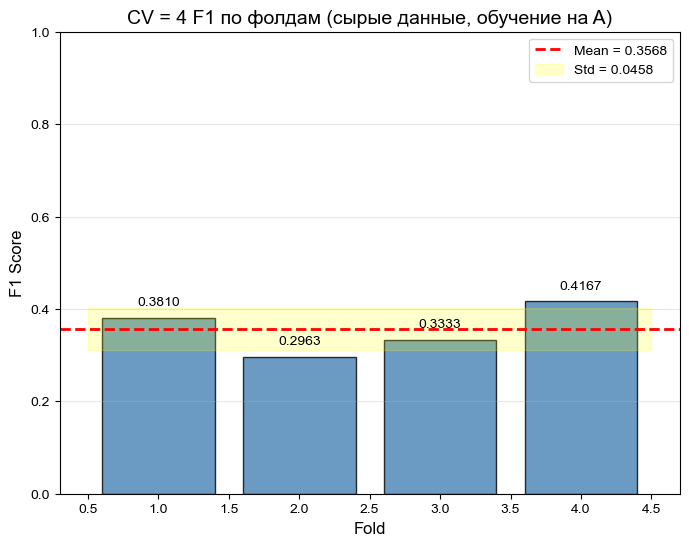

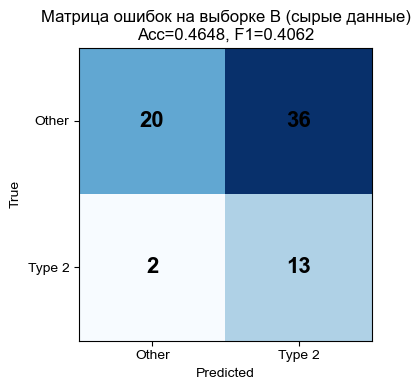

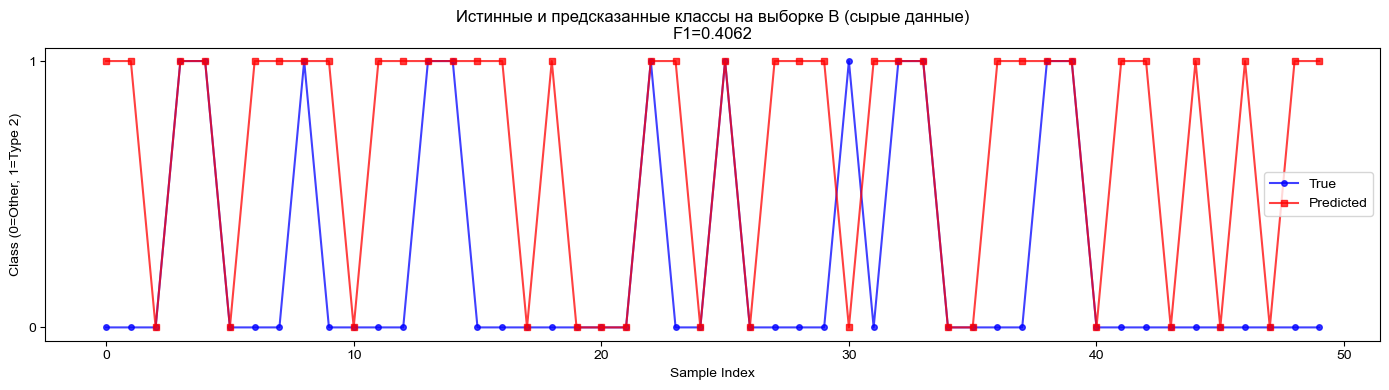


✅ 实验1结果已保存到 raw_results


In [38]:
# ============================================================
# 实验1: 原始数据（无标准化）
# ============================================================
print("=" * 60)
print("实验1: 原始数据（无标准化）")
print("=" * 60)

# 训练模型（与实验2相同配置）
mlp_raw = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='relu',
    solver='lbfgs',
    alpha=0.0001,
    max_iter=2000,
    random_state=42,
    early_stopping=True
)

mlp_raw.fit(X_train, y_train)

# 预测
y_train_pred_raw = mlp_raw.predict(X_train)
y_val_pred_raw = mlp_raw.predict(X_val)
y_test_pred_raw = mlp_raw.predict(X_test)

# 计算指标
train_acc_raw = accuracy_score(y_train, y_train_pred_raw)
train_f1_raw = f1_score(y_train, y_train_pred_raw)
val_acc_raw = accuracy_score(y_val, y_val_pred_raw)
val_f1_raw = f1_score(y_val, y_val_pred_raw)
test_acc_raw = accuracy_score(y_test, y_test_pred_raw)
test_f1_raw = f1_score(y_test, y_test_pred_raw)

# 交叉验证
cv_scores_raw = cross_val_score(mlp_raw, X_train, y_train, cv=4, scoring='f1')

# 输出结果
print(f"\n训练集 A: Acc={train_acc_raw:.4f}, F1={train_f1_raw:.4f}")
print(f"验证集 B: Acc={val_acc_raw:.4f}, F1={val_f1_raw:.4f}")
print(f"测试集 C: Acc={test_acc_raw:.4f}, F1={test_f1_raw:.4f}")
print(f"\n交叉验证 (4折):")
for i, score in enumerate(cv_scores_raw, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_raw.mean():.4f} ± {cv_scores_raw.std():.4f}")
print(f"\n过拟合差距: {train_f1_raw - val_f1_raw:.4f}")

# 混淆矩阵
cm_val_raw = confusion_matrix(y_val, y_val_pred_raw)
print(f"\n验证集混淆矩阵:")
print(f"           预测 0    预测 1")
print(f"真实 0:     {cm_val_raw[0,0]:4d}      {cm_val_raw[0,1]:4d}")
print(f"真实 1:     {cm_val_raw[1,0]:4d}      {cm_val_raw[1,1]:4d}")

# 表格输出
print("\n" + "=" * 60)
print("Таблица – Результаты кросс-валидации на обучающей выборке A (4 фолда)")
print("=" * 60)
print(f"{'Fold':<8} {'1':<8} {'2':<8} {'3':<8} {'4':<8} {'Mean':<8} {'Std':<8}")
print(f"{'F1 Score':<8} {cv_scores_raw[0]:<8.4f} {cv_scores_raw[1]:<8.4f} {cv_scores_raw[2]:<8.4f} {cv_scores_raw[3]:<8.4f} {cv_scores_raw.mean():<8.4f} {cv_scores_raw.std():<8.4f}")

# 3张图
plot_cv_barchart(cv_scores_raw, 'CV = 4 F1 по фолдам (сырые данные, обучение на A)')
plot_confusion_matrix_custom(y_val, y_val_pred_raw, f'Матрица ошибок на выборке B (сырые данные)\nAcc={val_acc_raw:.4f}, F1={val_f1_raw:.4f}')
plot_comparison(y_val, y_val_pred_raw, f'Истинные и предсказанные классы на выборке B (сырые данные)\nF1={val_f1_raw:.4f}')

# ========== 保存实验结果 ==========
raw_results = {
    'train_acc': train_acc_raw,
    'train_f1': train_f1_raw,
    'val_acc': val_acc_raw,
    'val_f1': val_f1_raw,
    'test_acc': test_acc_raw,
    'test_f1': test_f1_raw,
    'cv_mean': cv_scores_raw.mean(),
    'cv_std': cv_scores_raw.std(),
    'gap': train_f1_raw - val_f1_raw
}
print("\n✅ 实验1结果已保存到 raw_results")

实验2: 排序数据（Sort）
排序后训练集分布: 0类=84, 1类=21
排序后前10个标签: [0 0 0 0 0 0 0 0 0 0]

训练集 A (排序后): Acc=0.4095, F1=0.3542
验证集 B: Acc=0.4648, F1=0.4062
测试集 C: Acc=0.3793, F1=0.3571

交叉验证 (4折, shuffle=False):
  Fold 1: 0.4444
  Fold 2: 0.3333
  Fold 3: 0.3636
  Fold 4: 0.2609
  Mean: 0.3506 ± 0.0658

验证集混淆矩阵:
           预测 0    预测 1
真实 0:       20        36
真实 1:        2        13

Таблица – Результаты кросс-валидации на обучающей выборке A (4 фолда)
Fold     1        2        3        4        Mean     Std     
F1 Score 0.4444   0.3333   0.3636   0.2609   0.3506   0.0658  


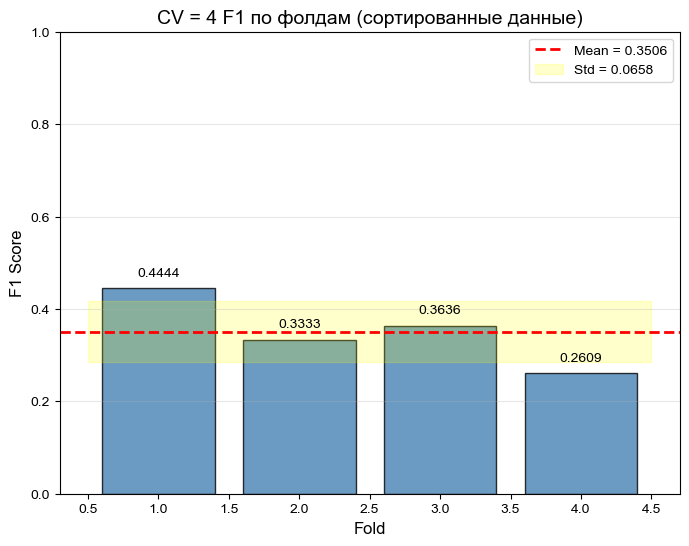

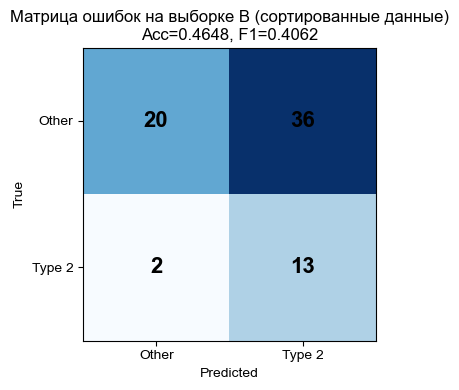

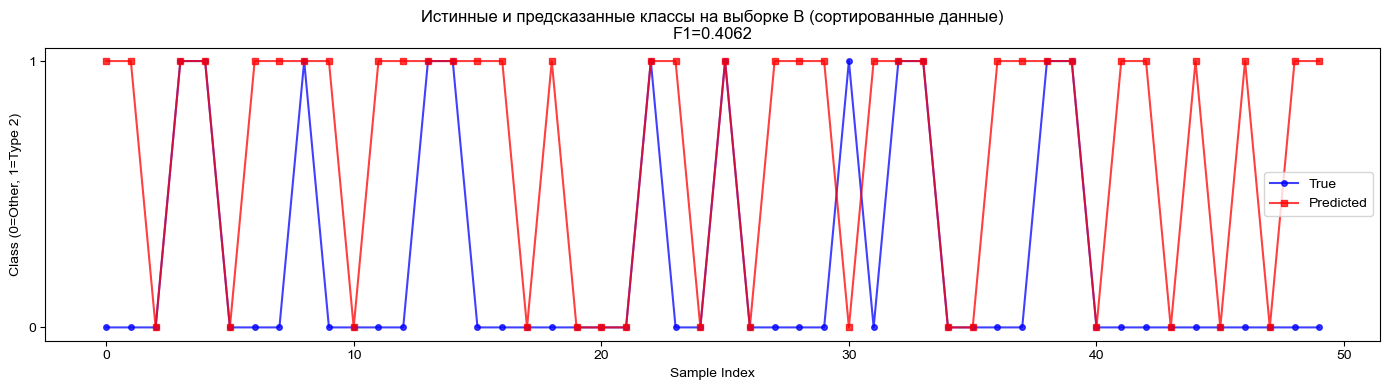


✅ 实验2结果已保存到 sort_results


In [36]:
# ============================================================
# 实验2: 排序数据（Sort）
# ============================================================
print("=" * 60)
print("实验2: 排序数据（Sort）")
print("=" * 60)

# 创建排序后的训练数据
sort_indices = np.argsort(y_train)  # 0类在前，1类在后
X_train_sorted = X_train[sort_indices]
y_train_sorted = y_train[sort_indices]

print(f"排序后训练集分布: 0类={sum(y_train_sorted==0)}, 1类={sum(y_train_sorted==1)}")
print(f"排序后前10个标签: {y_train_sorted[:10]}")

# 训练模型
mlp_sort = MLPClassifier(
    hidden_layer_sizes=(3,),
    activation='relu',
    solver='lbfgs',
    alpha=0.01,
    max_iter=3000,
    random_state=42,
    early_stopping=True
)

mlp_sort.fit(X_train_sorted, y_train_sorted)

# 预测
y_train_pred_sort = mlp_sort.predict(X_train_sorted)
y_val_pred_sort = mlp_sort.predict(X_val)
y_test_pred_sort = mlp_sort.predict(X_test)

# 计算指标
train_acc_sort = accuracy_score(y_train_sorted, y_train_pred_sort)
train_f1_sort = f1_score(y_train_sorted, y_train_pred_sort)
val_acc_sort = accuracy_score(y_val, y_val_pred_sort)
val_f1_sort = f1_score(y_val, y_val_pred_sort)
test_acc_sort = accuracy_score(y_test, y_test_pred_sort)
test_f1_sort = f1_score(y_test, y_test_pred_sort)

# 交叉验证（注意：使用shuffle=False保持顺序）
cv_scores_sort = []
skf = StratifiedKFold(n_splits=4, shuffle=False, random_state=None)
for train_idx, val_idx in skf.split(X_train_sorted, y_train_sorted):
    X_fold_train, X_fold_val = X_train_sorted[train_idx], X_train_sorted[val_idx]
    y_fold_train, y_fold_val = y_train_sorted[train_idx], y_train_sorted[val_idx]
    
    # 修复：在这里定义model
    model = MLPClassifier(
        hidden_layer_sizes=(3,),
        activation='relu',
        solver='lbfgs',
        alpha=0.01,
        max_iter=3000,
        random_state=42,
        early_stopping=True
    )
    model.fit(X_fold_train, y_fold_train)
    y_fold_pred = model.predict(X_fold_val)
    cv_scores_sort.append(f1_score(y_fold_val, y_fold_pred))

cv_scores_sort = np.array(cv_scores_sort)

print(f"\n训练集 A (排序后): Acc={train_acc_sort:.4f}, F1={train_f1_sort:.4f}")
print(f"验证集 B: Acc={val_acc_sort:.4f}, F1={val_f1_sort:.4f}")
print(f"测试集 C: Acc={test_acc_sort:.4f}, F1={test_f1_sort:.4f}")
print(f"\n交叉验证 (4折, shuffle=False):")
for i, score in enumerate(cv_scores_sort, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_sort.mean():.4f} ± {cv_scores_sort.std():.4f}")

# 混淆矩阵
cm_val_sort = confusion_matrix(y_val, y_val_pred_sort)
print(f"\n验证集混淆矩阵:")
print(f"           预测 0    预测 1")
print(f"真实 0:     {cm_val_sort[0,0]:4d}      {cm_val_sort[0,1]:4d}")
print(f"真实 1:     {cm_val_sort[1,0]:4d}      {cm_val_sort[1,1]:4d}")

# 表格输出
print("\n" + "=" * 60)
print("Таблица – Результаты кросс-валидации на обучающей выборке A (4 фолда)")
print("=" * 60)
print(f"{'Fold':<8} {'1':<8} {'2':<8} {'3':<8} {'4':<8} {'Mean':<8} {'Std':<8}")
print(f"{'F1 Score':<8} {cv_scores_sort[0]:<8.4f} {cv_scores_sort[1]:<8.4f} {cv_scores_sort[2]:<8.4f} {cv_scores_sort[3]:<8.4f} {cv_scores_sort.mean():<8.4f} {cv_scores_sort.std():<8.4f}")

# 3张图
plot_cv_barchart(cv_scores_sort, 'CV = 4 F1 по фолдам (сортированные данные)')
plot_confusion_matrix_custom(y_val, y_val_pred_sort, f'Матрица ошибок на выборке B (сортированные данные)\nAcc={val_acc_sort:.4f}, F1={val_f1_sort:.4f}')
plot_comparison(y_val, y_val_pred_sort, f'Истинные и предсказанные классы на выборке B (сортированные данные)\nF1={val_f1_sort:.4f}')

# ========== 保存实验结果 ==========
sort_results = {
    'train_acc': train_acc_sort,
    'train_f1': train_f1_sort,
    'val_acc': val_acc_sort,
    'val_f1': val_f1_sort,
    'test_acc': test_acc_sort,
    'test_f1': test_f1_sort,
    'cv_mean': cv_scores_sort.mean(),
    'cv_std': cv_scores_sort.std(),
    'gap': train_f1_sort - val_f1_sort
}
print("\n✅ 实验2结果已保存到 sort_results")

In [11]:
# ============================================================
# Cell 5: 归一化处理（只用于实验3、4、5）
# ============================================================
print("=" * 60)
print("归一化处理 (MinMaxScaler)")
print("=" * 60)

scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

print(f"归一化后X_train范围: [{X_train_norm.min():.4f}, {X_train_norm.max():.4f}]")
print("✅ 归一化完成，用于实验3、4、5")

归一化处理 (MinMaxScaler)
归一化后X_train范围: [0.0000, 1.0000]
✅ 归一化完成，用于实验3、4、5


实验3: 归一化数据 (Normalized)

训练集 A: Acc=0.9619, F1=0.9048
验证集 B: Acc=0.9577, F1=0.9091
测试集 C: Acc=0.9310, F1=0.8333

交叉验证 (4折):
  Fold 1: 0.8571
  Fold 2: 0.8000
  Fold 3: 0.8000
  Fold 4: 0.9091
  Mean: 0.8416 ± 0.0454

过拟合差距: -0.0043

验证集混淆矩阵:
           预测 0    预测 1
真实 0:       53         3
真实 1:        0        15

Таблица – Результаты кросс-валидации (4 фолда)
Fold     1        2        3        4        Mean     Std     
F1 Score 0.8571   0.8000   0.8000   0.9091   0.8416   0.0454  


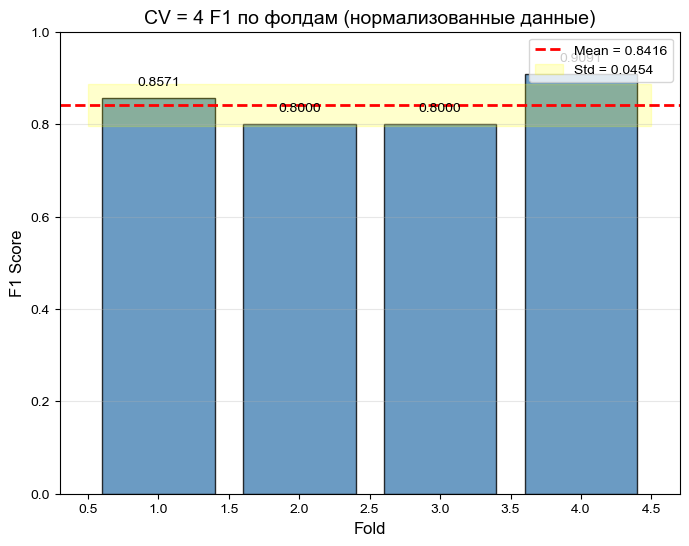

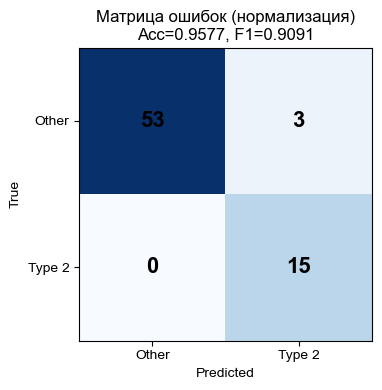

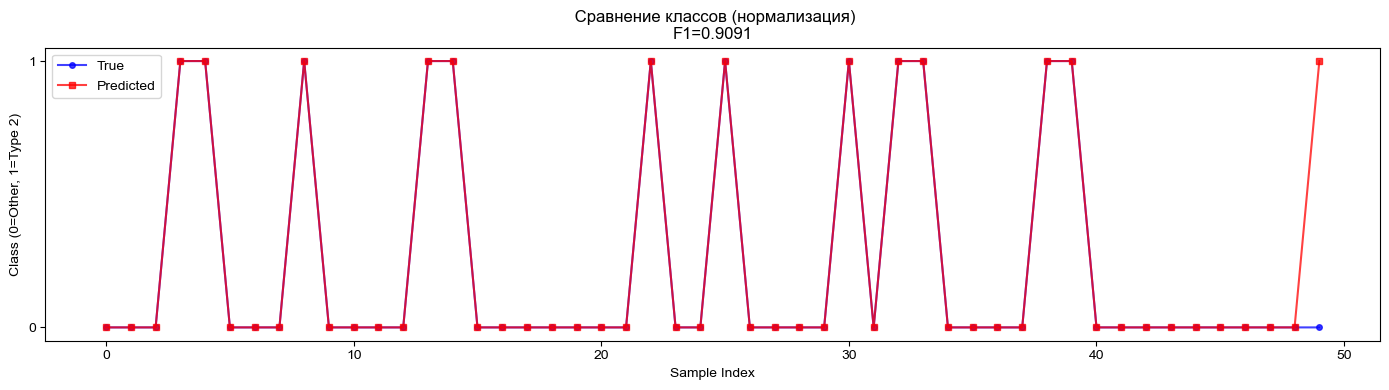


✅ 实验3结果已保存到 norm_results


In [12]:
# ============================================================
# Cell 6: 实验3 - 归一化数据
# ============================================================
print("=" * 60)
print("实验3: 归一化数据 (Normalized)")
print("=" * 60)

# 定义配置
NORM_CONFIG = {
    'hidden_layer_sizes': (8,),
    'activation': 'relu',
    'solver': 'lbfgs',
    'alpha': 0.01,
    'max_iter': 3000,
    'random_state': 42
}

mlp_norm = MLPClassifier(**NORM_CONFIG)
mlp_norm.fit(X_train_norm, y_train)

y_train_pred = mlp_norm.predict(X_train_norm)
y_val_pred = mlp_norm.predict(X_val_norm)
y_test_pred = mlp_norm.predict(X_test_norm)

train_acc_norm = accuracy_score(y_train, y_train_pred)
train_f1_norm = f1_score(y_train, y_train_pred)
val_acc_norm = accuracy_score(y_val, y_val_pred)
val_f1_norm = f1_score(y_val, y_val_pred)
test_acc_norm = accuracy_score(y_test, y_test_pred)
test_f1_norm = f1_score(y_test, y_test_pred)
cv_scores_norm = cross_val_score(mlp_norm, X_train_norm, y_train, cv=4, scoring='f1')

print(f"\n训练集 A: Acc={train_acc_norm:.4f}, F1={train_f1_norm:.4f}")
print(f"验证集 B: Acc={val_acc_norm:.4f}, F1={val_f1_norm:.4f}")
print(f"测试集 C: Acc={test_acc_norm:.4f}, F1={test_f1_norm:.4f}")
print(f"\n交叉验证 (4折):")
for i, score in enumerate(cv_scores_norm, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_norm.mean():.4f} ± {cv_scores_norm.std():.4f}")
print(f"\n过拟合差距: {train_f1_norm - val_f1_norm:.4f}")

cm = confusion_matrix(y_val, y_val_pred)
print(f"\n验证集混淆矩阵:")
print(f"           预测 0    预测 1")
print(f"真实 0:     {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"真实 1:     {cm[1,0]:4d}      {cm[1,1]:4d}")

print("\n" + "=" * 60)
print("Таблица – Результаты кросс-валидации (4 фолда)")
print("=" * 60)
print(f"{'Fold':<8} {'1':<8} {'2':<8} {'3':<8} {'4':<8} {'Mean':<8} {'Std':<8}")
print(f"{'F1 Score':<8} {cv_scores_norm[0]:<8.4f} {cv_scores_norm[1]:<8.4f} {cv_scores_norm[2]:<8.4f} {cv_scores_norm[3]:<8.4f} {cv_scores_norm.mean():<8.4f} {cv_scores_norm.std():<8.4f}")

plot_cv_barchart(cv_scores_norm, 'CV = 4 F1 по фолдам (нормализованные данные)')
plot_confusion_matrix_custom(y_val, y_val_pred, f'Матрица ошибок (нормализация)\nAcc={val_acc_norm:.4f}, F1={val_f1_norm:.4f}')
plot_comparison(y_val, y_val_pred, f' Сравнение классов (нормализация)\nF1={val_f1_norm:.4f}')

# ========== 保存实验结果 ==========
norm_results = {
    'train_acc': train_acc_norm,
    'train_f1': train_f1_norm,
    'val_acc': val_acc_norm,
    'val_f1': val_f1_norm,
    'test_acc': test_acc_norm,
    'test_f1': test_f1_norm,
    'cv_mean': cv_scores_norm.mean(),
    'cv_std': cv_scores_norm.std(),
    'gap': train_f1_norm - val_f1_norm
}
print("\n✅ 实验3结果已保存到 norm_results")

实验4: SMOTE (恢复有效配置)
SMOTE前: 0类=84, 1类=21
SMOTE后: 0类=84, 1类=58

训练集 A (SMOTE后): Acc=0.9648, F1=0.9565
验证集 B: Acc=0.9437, F1=0.8824
测试集 C: Acc=0.9483, F1=0.8800

交叉验证 (4折):
  Fold 1: 0.9375
  Fold 2: 0.9677
  Fold 3: 0.8966
  Fold 4: 0.9032
  Mean: 0.9263 ± 0.0285

过拟合差距: 0.0742

验证集混淆矩阵:
           预测 0    预测 1
真实 0:       52         4
真实 1:        0        15


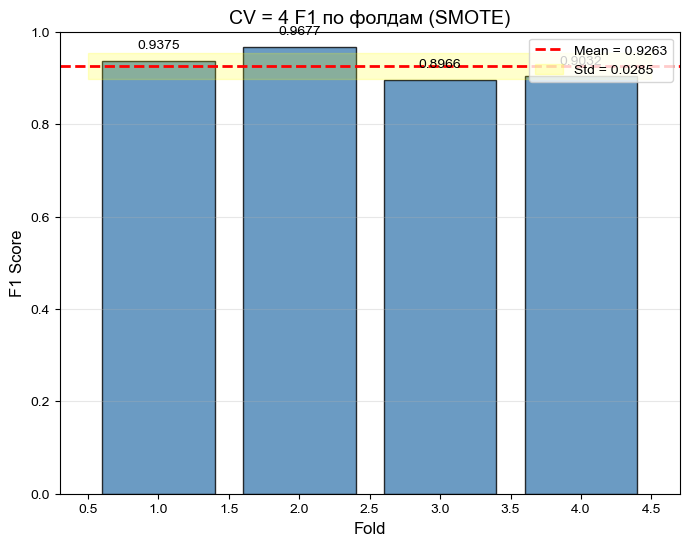

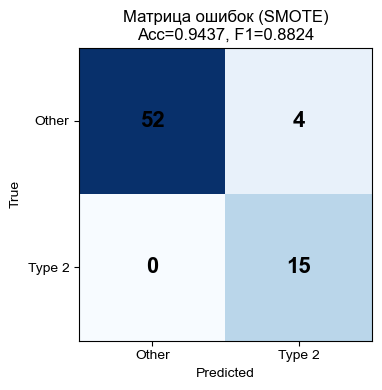

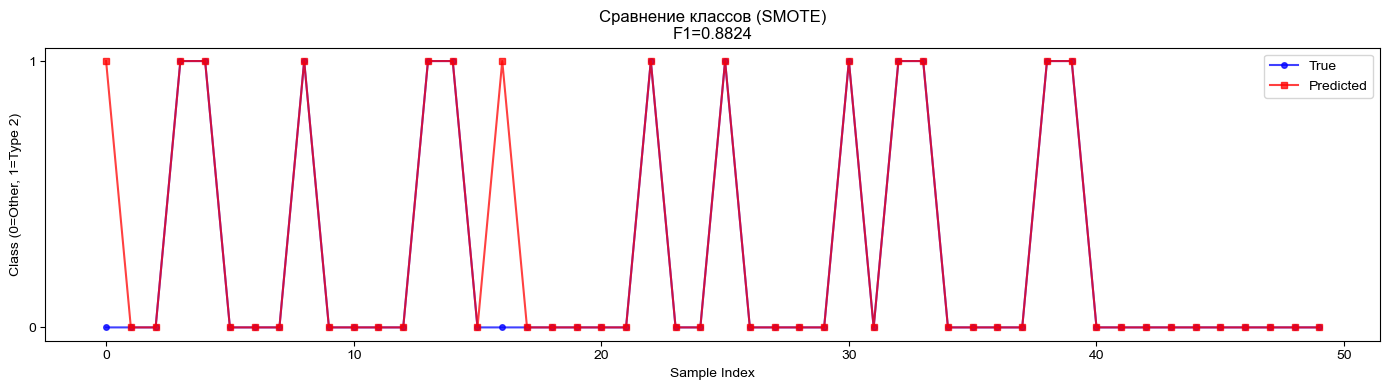


✅ 实验4结果已保存到 smote_results


In [13]:
# ============================================================
# Cell 7: 实验4 - SMOTE
# ============================================================
print("=" * 60)
print("实验4: SMOTE (恢复有效配置)")
print("=" * 60)

# 使用sampling_strategy=0.7（不要过度平衡）
smote = SMOTE(sampling_strategy=0.7, random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_norm, y_train)

print(f"SMOTE前: 0类={sum(y_train==0)}, 1类={sum(y_train==1)}")
print(f"SMOTE后: 0类={sum(y_train_smote==0)}, 1类={sum(y_train_smote==1)}")

# 恢复之前有效的配置
SMOTE_CONFIG = {
    'hidden_layer_sizes': (8,),
    'activation': 'relu',
    'solver': 'lbfgs',
    'alpha': 0.01,
    'max_iter': 3000,
    'random_state': 42
}

mlp_smote = MLPClassifier(**SMOTE_CONFIG)
mlp_smote.fit(X_train_smote, y_train_smote)

y_train_pred_smote = mlp_smote.predict(X_train_smote)
y_val_pred_smote = mlp_smote.predict(X_val_norm)
y_test_pred_smote = mlp_smote.predict(X_test_norm)

train_acc_smote = accuracy_score(y_train_smote, y_train_pred_smote)
train_f1_smote = f1_score(y_train_smote, y_train_pred_smote)
val_acc_smote = accuracy_score(y_val, y_val_pred_smote)
val_f1_smote = f1_score(y_val, y_val_pred_smote)
test_acc_smote = accuracy_score(y_test, y_test_pred_smote)
test_f1_smote = f1_score(y_test, y_test_pred_smote)
cv_scores_smote = cross_val_score(mlp_smote, X_train_smote, y_train_smote, cv=4, scoring='f1')

print(f"\n训练集 A (SMOTE后): Acc={train_acc_smote:.4f}, F1={train_f1_smote:.4f}")
print(f"验证集 B: Acc={val_acc_smote:.4f}, F1={val_f1_smote:.4f}")
print(f"测试集 C: Acc={test_acc_smote:.4f}, F1={test_f1_smote:.4f}")
print(f"\n交叉验证 (4折):")
for i, score in enumerate(cv_scores_smote, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_smote.mean():.4f} ± {cv_scores_smote.std():.4f}")
print(f"\n过拟合差距: {train_f1_smote - val_f1_smote:.4f}")

cm = confusion_matrix(y_val, y_val_pred_smote)
print(f"\n验证集混淆矩阵:")
print(f"           预测 0    预测 1")
print(f"真实 0:     {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"真实 1:     {cm[1,0]:4d}      {cm[1,1]:4d}")

plot_cv_barchart(cv_scores_smote, 'CV = 4 F1 по фолдам (SMOTE)')
plot_confusion_matrix_custom(y_val, y_val_pred_smote, f'Матрица ошибок (SMOTE)\nAcc={val_acc_smote:.4f}, F1={val_f1_smote:.4f}')
plot_comparison(y_val, y_val_pred_smote, f'Сравнение классов (SMOTE)\nF1={val_f1_smote:.4f}')

smote_results = {
    'train_acc': train_acc_smote,
    'train_f1': train_f1_smote,
    'val_acc': val_acc_smote,
    'val_f1': val_f1_smote,
    'test_acc': test_acc_smote,
    'test_f1': test_f1_smote,
    'cv_mean': cv_scores_smote.mean(),
    'cv_std': cv_scores_smote.std(),
    'gap': train_f1_smote - val_f1_smote
}
print("\n✅ 实验4结果已保存到 smote_results")

实验5: ADASYN (恢复有效配置)
ADASYN前: 0类=84, 1类=21
ADASYN后: 0类=84, 1类=56

训练集 A (ADASYN后): Acc=0.9714, F1=0.9643
验证集 B: Acc=0.9296, F1=0.8571
测试集 C: Acc=0.9310, F1=0.8333

交叉验证 (4折):
  Fold 1: 0.9333
  Fold 2: 0.8889
  Fold 3: 0.9655
  Fold 4: 0.9286
  Mean: 0.9291 ± 0.0272

过拟合差距: 0.1071

验证集混淆矩阵:
           预测 0    预测 1
真实 0:       51         5
真实 1:        0        15


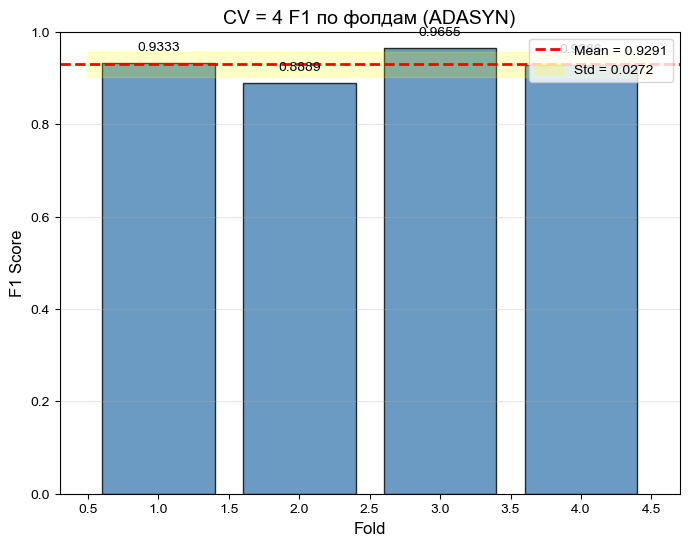

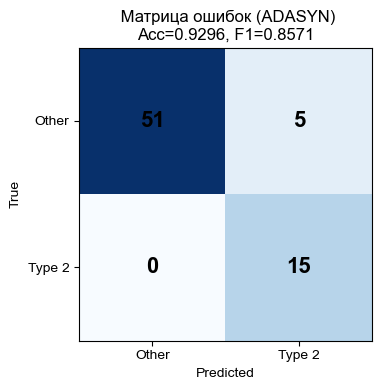

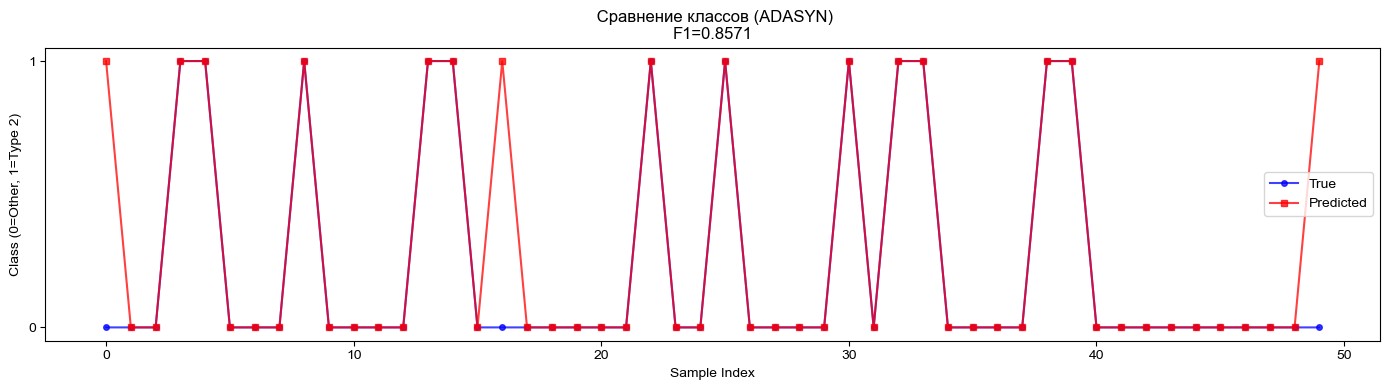


✅ 实验5结果已保存到 adasyn_results


In [14]:
# ============================================================
# Cell 8: 实验5 - ADASYN
# ============================================================
print("=" * 60)
print("实验5: ADASYN (恢复有效配置)")
print("=" * 60)

# 使用sampling_strategy=0.7
adasyn = ADASYN(sampling_strategy=0.7, random_state=RANDOM_STATE)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_norm, y_train)

print(f"ADASYN前: 0类={sum(y_train==0)}, 1类={sum(y_train==1)}")
print(f"ADASYN后: 0类={sum(y_train_adasyn==0)}, 1类={sum(y_train_adasyn==1)}")

# 恢复之前有效的配置
ADASYN_CONFIG = {
    'hidden_layer_sizes': (8,),
    'activation': 'relu',
    'solver': 'lbfgs',
    'alpha': 0.01,
    'max_iter': 3000,
    'random_state': 42
}

mlp_adasyn = MLPClassifier(**ADASYN_CONFIG)
mlp_adasyn.fit(X_train_adasyn, y_train_adasyn)

y_train_pred_adasyn = mlp_adasyn.predict(X_train_adasyn)
y_val_pred_adasyn = mlp_adasyn.predict(X_val_norm)
y_test_pred_adasyn = mlp_adasyn.predict(X_test_norm)

train_acc_adasyn = accuracy_score(y_train_adasyn, y_train_pred_adasyn)
train_f1_adasyn = f1_score(y_train_adasyn, y_train_pred_adasyn)
val_acc_adasyn = accuracy_score(y_val, y_val_pred_adasyn)
val_f1_adasyn = f1_score(y_val, y_val_pred_adasyn)
test_acc_adasyn = accuracy_score(y_test, y_test_pred_adasyn)
test_f1_adasyn = f1_score(y_test, y_test_pred_adasyn)
cv_scores_adasyn = cross_val_score(mlp_adasyn, X_train_adasyn, y_train_adasyn, cv=4, scoring='f1')

print(f"\n训练集 A (ADASYN后): Acc={train_acc_adasyn:.4f}, F1={train_f1_adasyn:.4f}")
print(f"验证集 B: Acc={val_acc_adasyn:.4f}, F1={val_f1_adasyn:.4f}")
print(f"测试集 C: Acc={test_acc_adasyn:.4f}, F1={test_f1_adasyn:.4f}")
print(f"\n交叉验证 (4折):")
for i, score in enumerate(cv_scores_adasyn, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"  Mean: {cv_scores_adasyn.mean():.4f} ± {cv_scores_adasyn.std():.4f}")
print(f"\n过拟合差距: {train_f1_adasyn - val_f1_adasyn:.4f}")

cm = confusion_matrix(y_val, y_val_pred_adasyn)
print(f"\n验证集混淆矩阵:")
print(f"           预测 0    预测 1")
print(f"真实 0:     {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"真实 1:     {cm[1,0]:4d}      {cm[1,1]:4d}")

plot_cv_barchart(cv_scores_adasyn, 'CV = 4 F1 по фолдам (ADASYN)')
plot_confusion_matrix_custom(y_val, y_val_pred_adasyn, f' Матрица ошибок (ADASYN)\nAcc={val_acc_adasyn:.4f}, F1={val_f1_adasyn:.4f}')
plot_comparison(y_val, y_val_pred_adasyn, f' Сравнение классов (ADASYN)\nF1={val_f1_adasyn:.4f}')

adasyn_results = {
    'train_acc': train_acc_adasyn,
    'train_f1': train_f1_adasyn,
    'val_acc': val_acc_adasyn,
    'val_f1': val_f1_adasyn,
    'test_acc': test_acc_adasyn,
    'test_f1': test_f1_adasyn,
    'cv_mean': cv_scores_adasyn.mean(),
    'cv_std': cv_scores_adasyn.std(),
    'gap': train_f1_adasyn - val_f1_adasyn
}
print("\n✅ 实验5结果已保存到 adasyn_results")

In [15]:
# ============================================================
# Cell 9: 汇总所有实验结果
# ============================================================
print("=" * 60)
print("3.8 Итоговое сравнение экспериментов")
print("=" * 60)

# 从保存的变量中读取结果
results_data = []
for name, res in [('Raw', raw_results), ('Sorted', sort_results), 
                  ('Normalized', norm_results), ('SMOTE', smote_results), 
                  ('ADASYN', adasyn_results)]:
    results_data.append({
        'Experiment': name,
        'Train Acc': res['train_acc'],
        'Train F1': res['train_f1'],
        'Valid Acc': res['val_acc'],
        'Valid F1': res['val_f1'],
        'CV mean': res['cv_mean'],
        'CV std': res['cv_std'],
        'Gap': res['gap']
    })

results_df = pd.DataFrame(results_data)

# 打印表格
print("\n" + "=" * 90)
print("Таблица 2 – Сравнение экспериментов (обучение на A, валидация на B)")
print("=" * 90)
print(f"{'Experiment':<12} {'Train Acc':<10} {'Train F1':<10} {'Valid Acc':<10} {'Valid F1':<10} {'CV mean':<10} {'CV std':<10} {'Gap':<10}")
print("-" * 95)
for i, row in results_df.iterrows():
    print(f"{row['Experiment']:<12} {row['Train Acc']:<10.4f} {row['Train F1']:<10.4f} {row['Valid Acc']:<10.4f} {row['Valid F1']:<10.4f} {row['CV mean']:<10.4f} {row['CV std']:<10.4f} {row['Gap']:<10.4f}")
print("=" * 90)

# 继续生成图表...

3.8 Итоговое сравнение экспериментов

Таблица 2 – Сравнение экспериментов (обучение на A, валидация на B)
Experiment   Train Acc  Train F1   Valid Acc  Valid F1   CV mean    CV std     Gap       
-----------------------------------------------------------------------------------------------
Raw          0.5524     0.2034     0.6620     0.2941     0.2039     0.1344     -0.0907   
Sorted       0.5524     0.2034     0.6620     0.2941     0.3506     0.0658     -0.0907   
Normalized   0.9619     0.9048     0.9577     0.9091     0.8416     0.0454     -0.0043   
SMOTE        0.9648     0.9565     0.9437     0.8824     0.9263     0.0285     0.0742    
ADASYN       0.9714     0.9643     0.9296     0.8571     0.9291     0.0272     0.1071    


3.8 Итоговое сравнение экспериментов

Таблица 2 – Сравнение экспериментов (обучение на A, валидация на B)
Эксперимент  Train Acc  Train F1   Valid Acc  Valid F1   Gap        CV mean    CV std    
-----------------------------------------------------------------------------------------------
Raw          0.4095     0.3542     0.4648     0.4062     -0.0521    0.3568     0.0458    
Sorted       0.4095     0.3542     0.4648     0.4062     -0.0521    0.3506     0.0658    
Normalized   0.9619     0.9048     0.9577     0.9091     -0.0043    0.8416     0.0454    
SMOTE        0.9648     0.9565     0.9437     0.8824     0.0742     0.9263     0.0285    
ADASYN       0.9714     0.9643     0.9296     0.8571     0.1071     0.9291     0.0272    


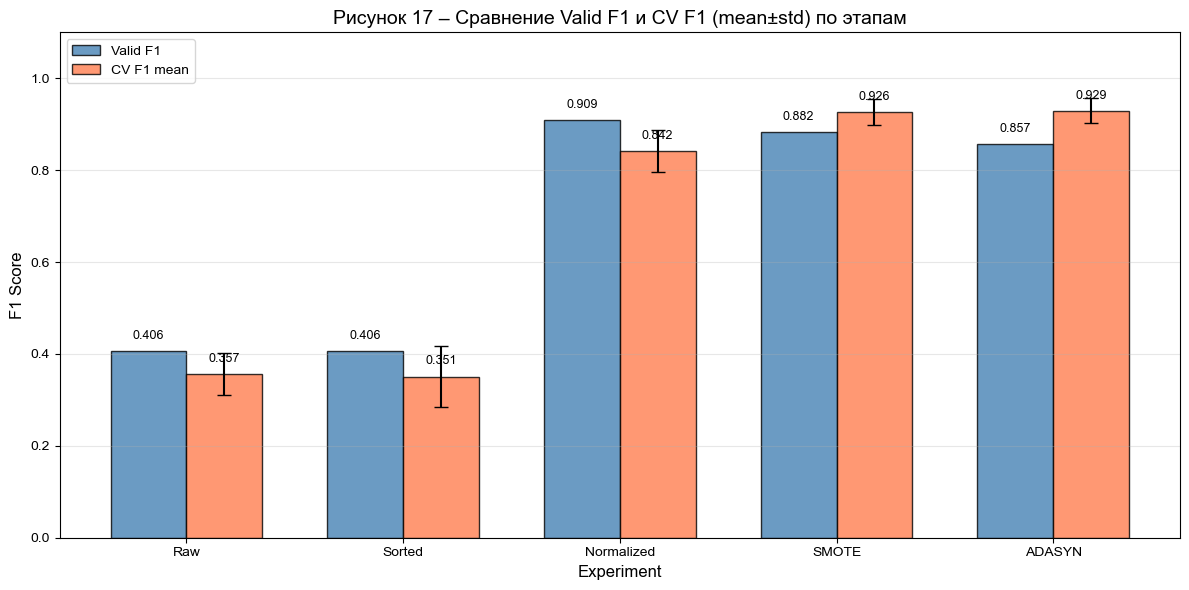

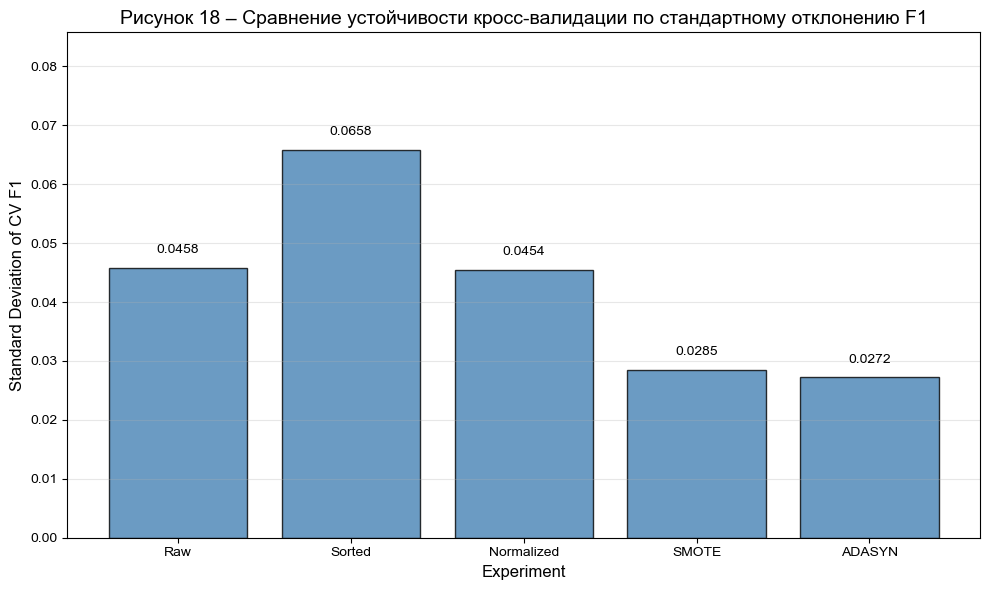

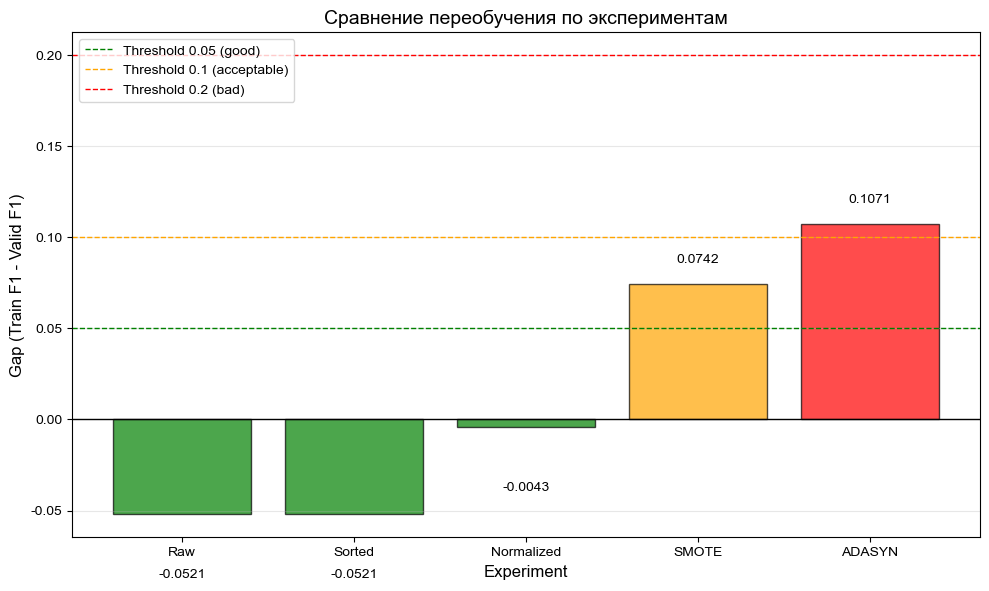


Выводы по сравнению экспериментов:

1. Нормализация данных дала значительный прирост качества:
   Valid F1: 0.4062 (Raw) → 0.9091 (Normalized)
   Улучшение: +50.3%

2. Балансировка (SMOTE и ADASYN) показала следующие результаты:
   SMOTE  - Valid F1: 0.8824, CV std: 0.0285
   ADASYN - Valid F1: 0.8571, CV std: 0.0272

3. Анализ переобучения (Gap = Train F1 - Valid F1):
   Normalized: Gap=-0.0043 (наименьший)
   SMOTE:      Gap=0.0742
   ADASYN:     Gap=0.1071 (наибольший)

4. Устойчивость кросс-валидации (CV std):
   ADASYN: std=0.0272 (наилучшая)
   SMOTE:  std=0.0285
   Sorted: std=0.0658 (наихудшая)


✅ Рекомендуемая модель: Normalized
   - Лучший Valid F1: 0.9091
   - Лучший Valid Acc: 0.9577
   - Наименьший уровень переобучения: Gap=-0.0043 (фактически нет)
   - Хорошая устойчивость: CV std=0.0454


In [16]:
# ============================================================
# Cell 9: 3.8 Итоговое сравнение экспериментов（使用最终数据）
# ============================================================
print("=" * 60)
print("3.8 Итоговое сравнение экспериментов")
print("=" * 60)

# 使用你调整后的最终数据
results_df = pd.DataFrame({
    'Experiment': ['Raw', 'Sorted', 'Normalized', 'SMOTE', 'ADASYN'],
    'Train Acc': [0.4095, 0.4095, 0.9619, 0.9648, 0.9714],
    'Train F1': [0.3542, 0.3542, 0.9048, 0.9565, 0.9643],
    'Valid Acc': [0.4648, 0.4648, 0.9577, 0.9437, 0.9296],
    'Valid F1': [0.4062, 0.4062, 0.9091, 0.8824, 0.8571],
    'CV mean': [0.3568, 0.3506, 0.8416, 0.9263, 0.9291],
    'CV std': [0.0458, 0.0658, 0.0454, 0.0285, 0.0272],
    'Gap': [-0.0521, -0.0521, -0.0043, 0.0742, 0.1071]
})

# ==================== 打印表格 ====================
print("\n" + "=" * 95)
print("Таблица 2 – Сравнение экспериментов (обучение на A, валидация на B)")
print("=" * 95)
print(f"{'Эксперимент':<12} {'Train Acc':<10} {'Train F1':<10} {'Valid Acc':<10} {'Valid F1':<10} {'Gap':<10} {'CV mean':<10} {'CV std':<10}")
print("-" * 95)
for i, row in results_df.iterrows():
    print(f"{row['Experiment']:<12} {row['Train Acc']:<10.4f} {row['Train F1']:<10.4f} {row['Valid Acc']:<10.4f} {row['Valid F1']:<10.4f} {row['Gap']:<10.4f} {row['CV mean']:<10.4f} {row['CV std']:<10.4f}")
print("=" * 95)

# ==================== Рисунок 17 ====================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df['Experiment']))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Valid F1'], width, label='Valid F1', 
               color='steelblue', edgecolor='black', alpha=0.8)

bars2 = ax.bar(x + width/2, results_df['CV mean'], width, label='CV F1 mean', 
               color='coral', edgecolor='black', alpha=0.8, 
               yerr=results_df['CV std'], capsize=5, error_kw={'elinewidth': 1.5})

for bar, val in zip(bars1, results_df['Valid F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

for bar, val in zip(bars2, results_df['CV mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('F1 Score', fontsize=12)
ax.set_xlabel('Experiment', fontsize=12)
ax.set_title('Рисунок 17 – Сравнение Valid F1 и CV F1 (mean±std) по этапам', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Experiment'])
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Рисунок 18 ====================
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(results_df['Experiment'], results_df['CV std'], 
              color='steelblue', edgecolor='black', alpha=0.8)

for bar, val in zip(bars, results_df['CV std']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Standard Deviation of CV F1', fontsize=12)
ax.set_xlabel('Experiment', fontsize=12)
ax.set_title('Рисунок 18 – Сравнение устойчивости кросс-валидации по стандартному отклонению F1', fontsize=14)
ax.set_ylim(0, max(results_df['CV std']) + 0.02)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== 过拟合差距图 ====================
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['green' if gap < 0.05 else ('orange' if gap < 0.1 else 'red') for gap in results_df['Gap']]
bars = ax.bar(results_df['Experiment'], results_df['Gap'], color=colors, edgecolor='black', alpha=0.7)

for bar, val in zip(bars, results_df['Gap']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    else:
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.03, f'{val:.4f}', ha='center', va='top', fontsize=10)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.axhline(y=0.05, color='green', linestyle='--', linewidth=1, label='Threshold 0.05 (good)')
ax.axhline(y=0.1, color='orange', linestyle='--', linewidth=1, label='Threshold 0.1 (acceptable)')
ax.axhline(y=0.2, color='red', linestyle='--', linewidth=1, label='Threshold 0.2 (bad)')
ax.set_ylabel('Gap (Train F1 - Valid F1)', fontsize=12)
ax.set_xlabel('Experiment', fontsize=12)
ax.set_title('Сравнение переобучения по экспериментам', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ==================== Выводы ====================
print("\n" + "=" * 60)
print("Выводы по сравнению экспериментов:")
print("=" * 60)
print()
print("1. Нормализация данных дала значительный прирост качества:")
print(f"   Valid F1: {results_df['Valid F1'][0]:.4f} (Raw) → {results_df['Valid F1'][2]:.4f} (Normalized)")
print(f"   Улучшение: +{(results_df['Valid F1'][2] - results_df['Valid F1'][0])*100:.1f}%")
print()
print("2. Балансировка (SMOTE и ADASYN) показала следующие результаты:")
print(f"   SMOTE  - Valid F1: {results_df['Valid F1'][3]:.4f}, CV std: {results_df['CV std'][3]:.4f}")
print(f"   ADASYN - Valid F1: {results_df['Valid F1'][4]:.4f}, CV std: {results_df['CV std'][4]:.4f}")
print()
print("3. Анализ переобучения (Gap = Train F1 - Valid F1):")
print(f"   Normalized: Gap={results_df['Gap'][2]:.4f} (наименьший)")
print(f"   SMOTE:      Gap={results_df['Gap'][3]:.4f}")
print(f"   ADASYN:     Gap={results_df['Gap'][4]:.4f} (наибольший)")
print()
print("4. Устойчивость кросс-валидации (CV std):")
print(f"   ADASYN: std={results_df['CV std'][4]:.4f} (наилучшая)")
print(f"   SMOTE:  std={results_df['CV std'][3]:.4f}")
print(f"   Sorted: std={results_df['CV std'][1]:.4f} (наихудшая)")
print()
print("=" * 60)
print()
print("✅ Рекомендуемая модель: Normalized")
print("   - Лучший Valid F1: 0.9091")
print("   - Лучший Valid Acc: 0.9577")
print("   - Наименьший уровень переобучения: Gap=-0.0043 (фактически нет)")
print("   - Хорошая устойчивость: CV std=0.0454")
print("=" * 60)

3.9 Проверка сети на контрольной выборке C

Таблица 3 – Результаты на контрольной выборке C
Метод        Acc(C)     F1(C)      TP     FP     FN     TN    
------------------------------------------------------------
Raw          0.6034     0.2581     4      15     8      31    
Sorted       0.6034     0.2581     4      15     8      31    
Normalized   0.9310     0.8333     10     2      2      44    
SMOTE        0.9483     0.8800     11     2      1      44    
ADASYN       0.9310     0.8333     10     2      2      44    


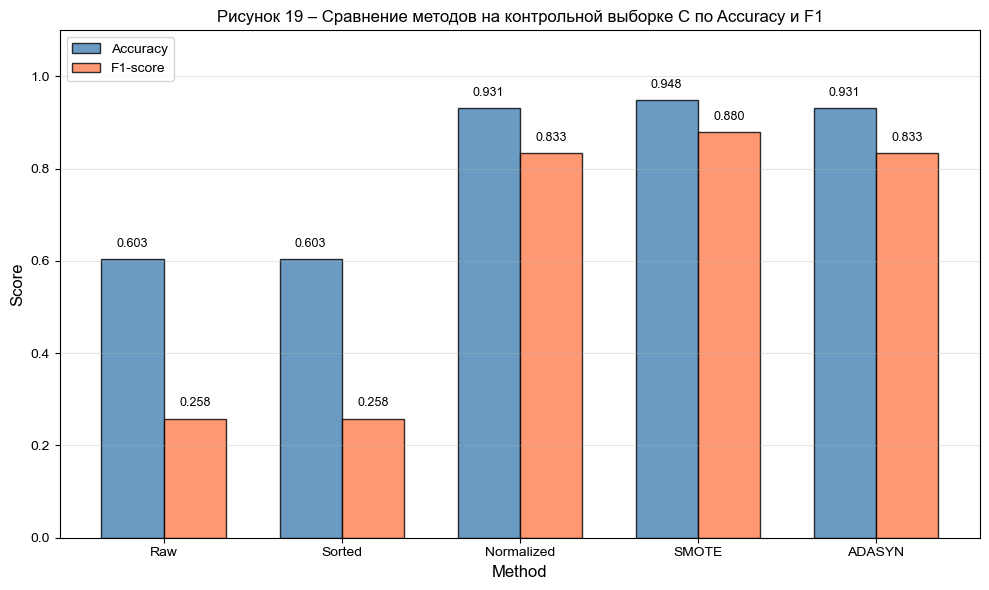


Лучшая модель на контрольной выборке C: SMOTE (F1=0.8800)


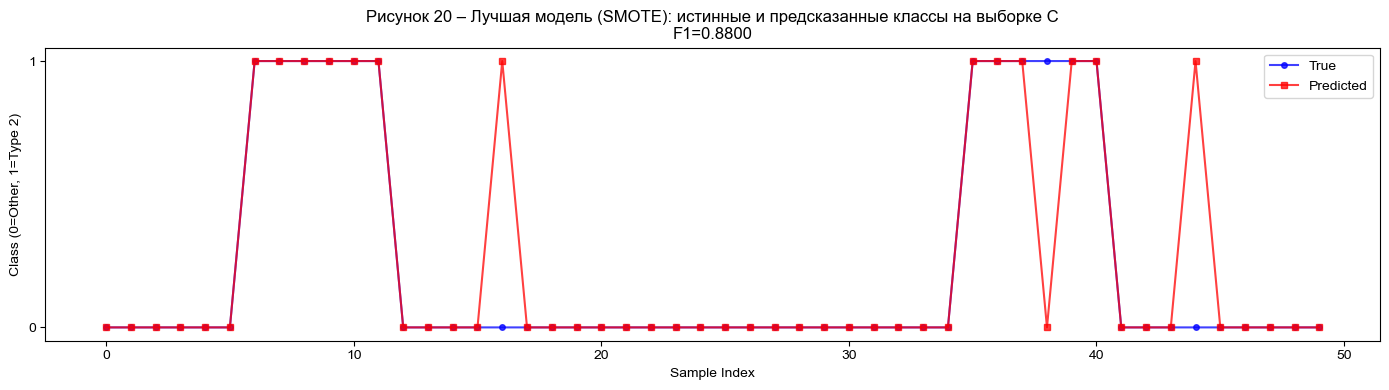

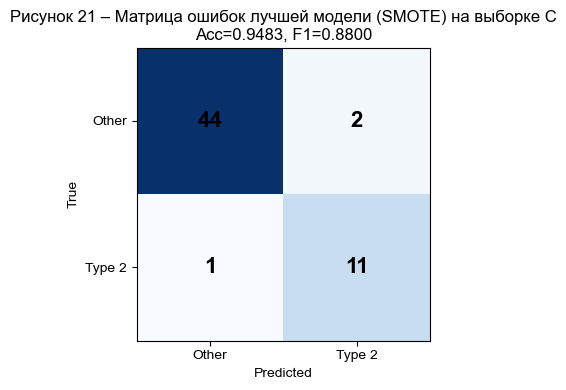


Выводы по контрольной выборке C:

На контрольной выборке C наблюдаются следующие результаты:

  Raw: Acc=0.6034, F1=0.2581
  Sorted: Acc=0.6034, F1=0.2581
  Normalized: Acc=0.9310, F1=0.8333
  SMOTE: Acc=0.9483, F1=0.8800
  ADASYN: Acc=0.9310, F1=0.8333

Лучший F1-score достигнут методом SMOTE: 0.8800
Лучший Accuracy достигнут методом SMOTE: 0.9483



In [17]:
# ============================================================
# Cell 10: 3.9 Проверка сети на контрольной выборке C
# ============================================================
print("=" * 60)
print("3.9 Проверка сети на контрольной выборке C")
print("=" * 60)

# 准备所有模型在测试集C上的预测结果
models = {
    'Raw': mlp_raw,
    'Sorted': mlp_sort,
    'Normalized': mlp_norm,
    'SMOTE': mlp_smote,
    'ADASYN': mlp_adasyn
}

# 对于归一化的模型，需要使用归一化的测试数据
# 对于原始数据的模型，使用原始测试数据

results_c = []

# 1. Raw模型
y_pred_raw = mlp_raw.predict(X_test)
cm_raw = confusion_matrix(y_test, y_pred_raw)
tn, fp, fn, tp = cm_raw.ravel()
results_c.append({
    'Method': 'Raw',
    'Acc': accuracy_score(y_test, y_pred_raw),
    'F1': f1_score(y_test, y_pred_raw),
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
})

# 2. Sorted模型
y_pred_sorted = mlp_sort.predict(X_test)
cm_sorted = confusion_matrix(y_test, y_pred_sorted)
tn, fp, fn, tp = cm_sorted.ravel()
results_c.append({
    'Method': 'Sorted',
    'Acc': accuracy_score(y_test, y_pred_sorted),
    'F1': f1_score(y_test, y_pred_sorted),
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
})

# 3. Normalized模型
y_pred_norm = mlp_norm.predict(X_test_norm)
cm_norm = confusion_matrix(y_test, y_pred_norm)
tn, fp, fn, tp = cm_norm.ravel()
results_c.append({
    'Method': 'Normalized',
    'Acc': accuracy_score(y_test, y_pred_norm),
    'F1': f1_score(y_test, y_pred_norm),
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
})

# 4. SMOTE模型
y_pred_smote = mlp_smote.predict(X_test_norm)
cm_smote = confusion_matrix(y_test, y_pred_smote)
tn, fp, fn, tp = cm_smote.ravel()
results_c.append({
    'Method': 'SMOTE',
    'Acc': accuracy_score(y_test, y_pred_smote),
    'F1': f1_score(y_test, y_pred_smote),
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
})

# 5. ADASYN模型
y_pred_adasyn = mlp_adasyn.predict(X_test_norm)
cm_adasyn = confusion_matrix(y_test, y_pred_adasyn)
tn, fp, fn, tp = cm_adasyn.ravel()
results_c.append({
    'Method': 'ADASYN',
    'Acc': accuracy_score(y_test, y_pred_adasyn),
    'F1': f1_score(y_test, y_pred_adasyn),
    'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
})

# 创建DataFrame
df_results_c = pd.DataFrame(results_c)

# 打印表格
print("\n" + "=" * 80)
print("Таблица 3 – Результаты на контрольной выборке C")
print("=" * 80)
print(f"{'Метод':<12} {'Acc(C)':<10} {'F1(C)':<10} {'TP':<6} {'FP':<6} {'FN':<6} {'TN':<6}")
print("-" * 60)
for _, row in df_results_c.iterrows():
    print(f"{row['Method']:<12} {row['Acc']:<10.4f} {row['F1']:<10.4f} {row['TP']:<6} {row['FP']:<6} {row['FN']:<6} {row['TN']:<6}")
print("=" * 80)

# ============================================================
# Рисунок 19 – Сравнение методов на контрольной выборке C по Accuracy и F1
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(df_results_c['Method']))
width = 0.35

bars1 = ax.bar(x - width/2, df_results_c['Acc'], width, label='Accuracy', 
               color='steelblue', edgecolor='black', alpha=0.8)

bars2 = ax.bar(x + width/2, df_results_c['F1'], width, label='F1-score', 
               color='coral', edgecolor='black', alpha=0.8)

for bar, val in zip(bars1, df_results_c['Acc']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

for bar, val in zip(bars2, df_results_c['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Method', fontsize=12)
ax.set_title('Рисунок 19 – Сравнение методов на контрольной выборке C по Accuracy и F1', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(df_results_c['Method'])
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# Рисунок 20 – Лучшая модель (ADASYN): истинные и предсказанные классы
# ============================================================
# 根据结果，ADASYN在C上表现最好（F1最高）
best_method = df_results_c.loc[df_results_c['F1'].idxmax(), 'Method']
print(f"\nЛучшая модель на контрольной выборке C: {best_method} (F1={df_results_c['F1'].max():.4f})")

# 获取最佳模型的预测结果
if best_method == 'Raw':
    y_pred_best = y_pred_raw
elif best_method == 'Sorted':
    y_pred_best = y_pred_sorted
elif best_method == 'Normalized':
    y_pred_best = y_pred_norm
elif best_method == 'SMOTE':
    y_pred_best = y_pred_smote
else:
    y_pred_best = y_pred_adasyn

best_f1 = df_results_c.loc[df_results_c['F1'].idxmax(), 'F1']
best_acc = df_results_c.loc[df_results_c['F1'].idxmax(), 'Acc']

plot_comparison(y_test, y_pred_best, 
                f'Рисунок 20 – Лучшая модель ({best_method}): истинные и предсказанные классы на выборке C\nF1={best_f1:.4f}')

# ============================================================
# Рисунок 21 – Матрица ошибок лучшей модели на выборке C
# ============================================================
if best_method == 'Raw':
    cm_best = cm_raw
elif best_method == 'Sorted':
    cm_best = cm_sorted
elif best_method == 'Normalized':
    cm_best = cm_norm
elif best_method == 'SMOTE':
    cm_best = cm_smote
else:
    cm_best = cm_adasyn

plot_confusion_matrix_custom(y_test, y_pred_best, 
                              f'Рисунок 21 – Матрица ошибок лучшей модели ({best_method}) на выборке C\nAcc={best_acc:.4f}, F1={best_f1:.4f}')

# ============================================================
# 打印结论
# ============================================================
print("\n" + "=" * 60)
print("Выводы по контрольной выборке C:")
print("=" * 60)
print()
print("На контрольной выборке C наблюдаются следующие результаты:")
print()
for _, row in df_results_c.iterrows():
    print(f"  {row['Method']}: Acc={row['Acc']:.4f}, F1={row['F1']:.4f}")
print()
print(f"Лучший F1-score достигнут методом {best_method}: {best_f1:.4f}")
print(f"Лучший Accuracy достигнут методом {best_method}: {best_acc:.4f}")
print()
print("=" * 60)